# **IMPORTING LIBRARIES**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')


In [8]:
pip install imbalanced-learn

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE

# **LOADING DATASET**

In [10]:
df=pd.read_csv("loan_data.csv")

# **DATASET OVERVIEW**

In [11]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [12]:
df.shape

(9578, 14)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [14]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

In [15]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# **CHECKING FOR NULL VALUES**

In [16]:
null_cnt=df.isnull().sum()
null_cnt

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


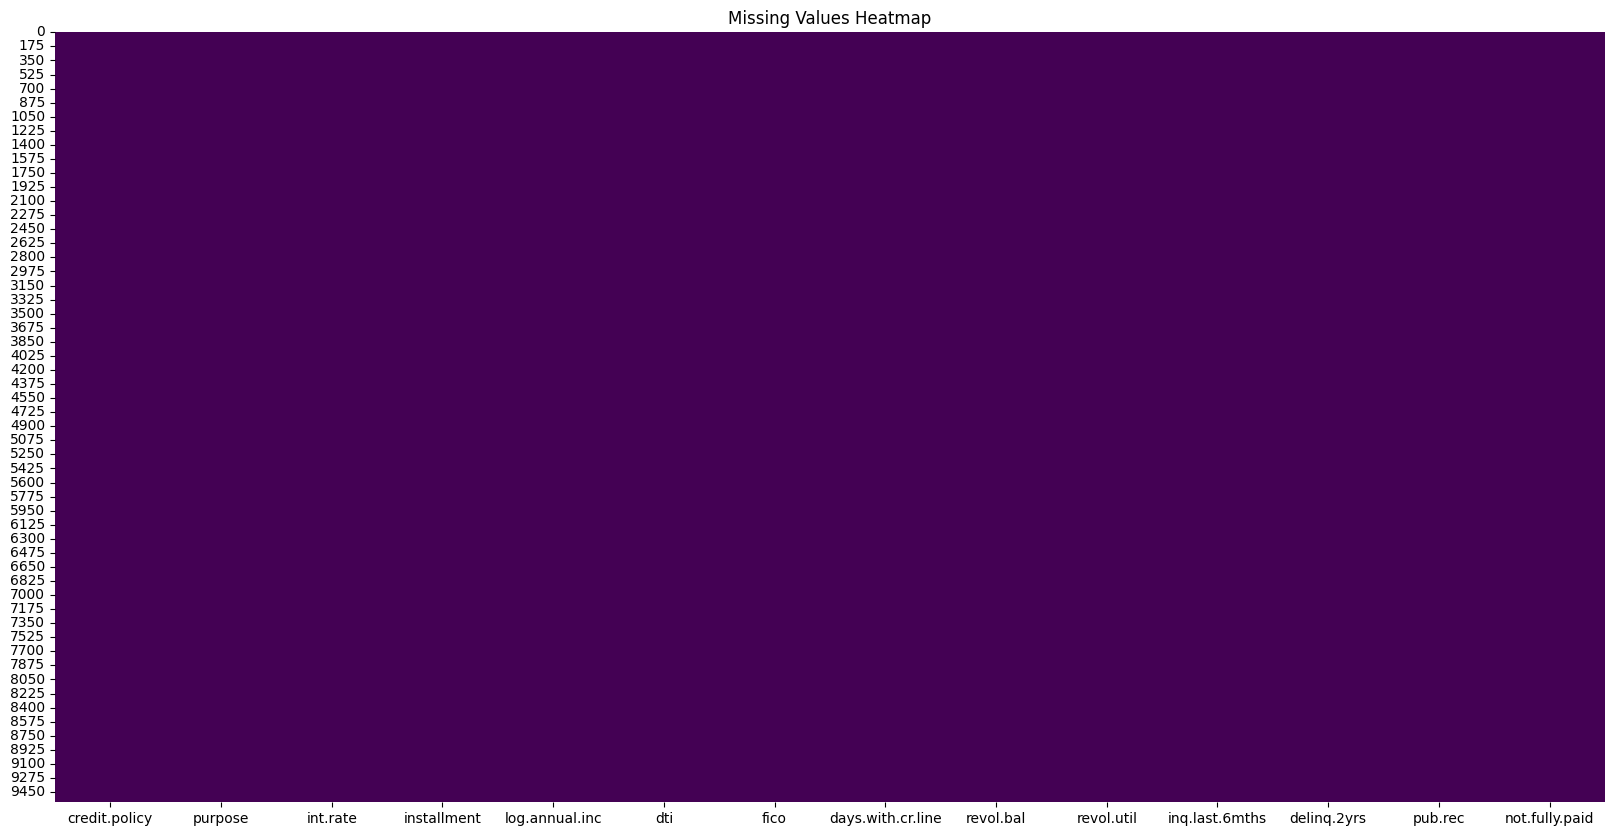

In [17]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

## **Observation**

1. The missing values heatmap is completely uniform, indicating that there are no missing (null) values present in any of the dataset's columns.

2. Since all features contain complete data, no missing value imputation or preprocessing for null values is required before performing further analysis or model building.

# **CHECKING FOR DUPLICATE VALUES**

In [18]:
dupl_cnt=df.duplicated().sum()
dupl_cnt

np.int64(0)

In [19]:
(df.select_dtypes(include='number')<0).sum()

,0
credit.policy,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0
inq.last.6mths,0


# **CHECKING FOR UNIQUE VALUES**

In [20]:
uniq_cnt=df.nunique()
uniq_cnt

,0
credit.policy,2
purpose,7
int.rate,249
installment,4788
log.annual.inc,1987
dti,2529
fico,44
days.with.cr.line,2687
revol.bal,7869
revol.util,1035


# **EXPLORATORY DATA ANALYSIS (EDA)**

In [21]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [22]:
df.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,debt_consolidation,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


## UNIVARIATE ANALYSIS

In [23]:
df["credit.policy"].value_counts()   #It displays the count of each target class

,count
credit.policy,
1,7710
0,1868


## DESCRIPTION

1-> Customer meets bank credit policy

0-> Customer does not meet the credit policy

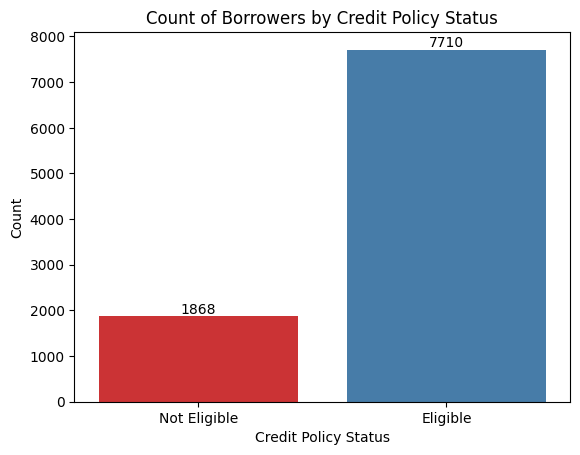

In [24]:
ax = sns.countplot(x="credit.policy", data=df, palette="Set1")

plt.xticks([0, 1], ["Not Eligible", "Eligible"])
plt.xlabel("Credit Policy Status")
plt.ylabel("Count")

for containers in ax.containers:
    ax.bar_label(containers)

plt.title("Count of Borrowers by Credit Policy Status")
plt.show()

## **OBSERVATION:**



*  Most borrowers satisfy the bank's credit policy (Met).
* Only a small number of borrowers do not satisfy the bank's credit policy (Not Met).



In [25]:
df["credit.policy"].value_counts(normalize=True)*100   #It displays the percentage of each target class

,proportion
credit.policy,
1,80.496972
0,19.503028


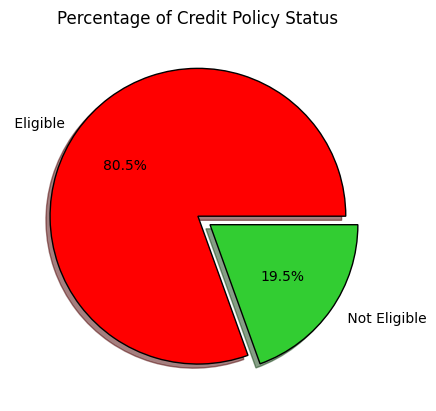

In [26]:
plt.pie(df["credit.policy"].value_counts(),autopct="%1.1f%%",shadow=True,labels=[" Eligible"," Not Eligible"],colors=['red','limegreen'],explode=[0,0.1],wedgeprops={'edgecolor':'black'})
plt.title("Percentage of Credit Policy Status")
plt.show()


*   Approximately 80% of borrowers satisfy the bank's credit policy (Eligible).
*   Approximately 20% of borrowers do not satisfy the bank's credit policy (Not Eligible).


In [27]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,3957
all_other,2331
credit_card,1262
home_improvement,629
small_business,619
major_purchase,437
educational,343


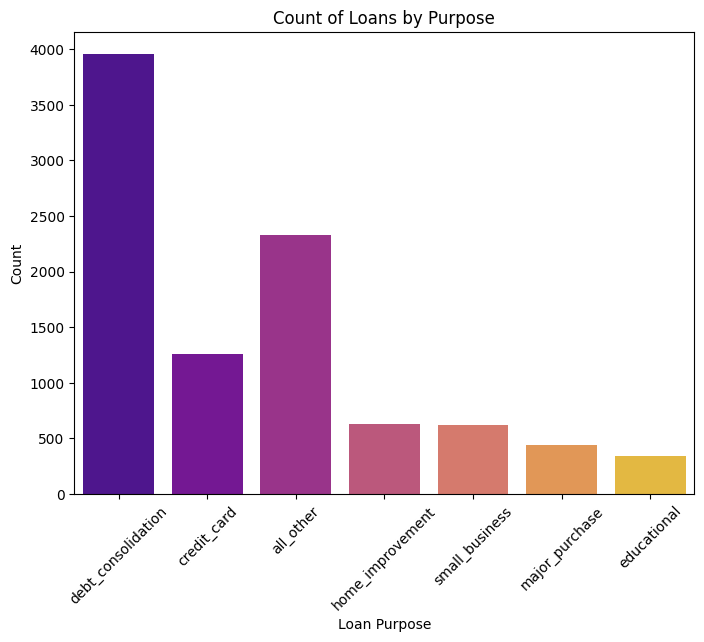

In [28]:
plt.figure(figsize=(8,6))
sns.countplot(x='purpose',data=df,palette='plasma')
plt.xticks(rotation=45)
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.title('Count of Loans by Purpose')
plt.show()

## **OBSERVATION**


*   debt_consolidation has highest count
*   educational loans have least count



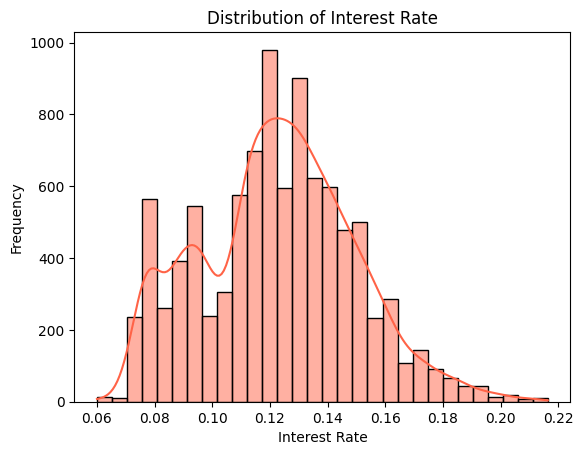

In [29]:
sns.histplot(df["int.rate"],kde=True,bins=30,color="tomato")
plt.title("Distribution of Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

## **OBSERVATION**



*   The distribution of interest rates is concentrated around 12–13%, indicating that most borrowers receive moderate interest rates.
* The distribution is slightly positively skewed, with relatively few borrowers receiving very high interest rates above 16%.
* This suggests that high-risk loans are less common in the dataset.




In [30]:
df['pub.rec'].value_counts()

,count
pub.rec,
0,9019
1,533
2,19
3,5
4,1
5,1


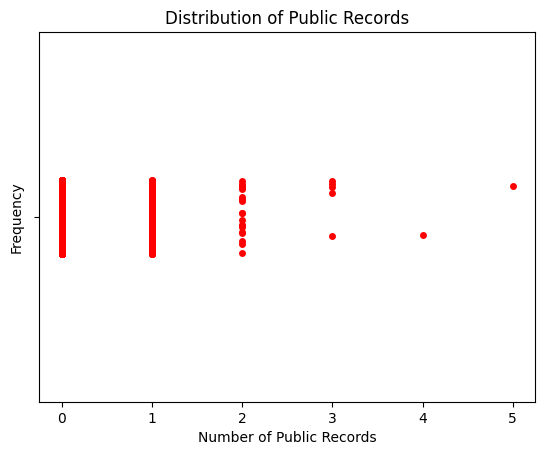

In [31]:
sns.stripplot(x=df['pub.rec'],color='red',jitter=True)
plt.title("Distribution of Public Records")
plt.xlabel("Number of Public Records")
plt.ylabel("Frequency")
plt.show()

## **OBSERVATION**

Most borrowers have zero to one public record(s), very few have more than one public records.

In [32]:
df['inq.last.6mths'].value_counts()


,count
inq.last.6mths,
0,3637
1,2462
2,1384
3,864
4,475
5,278
6,165
7,100
8,72


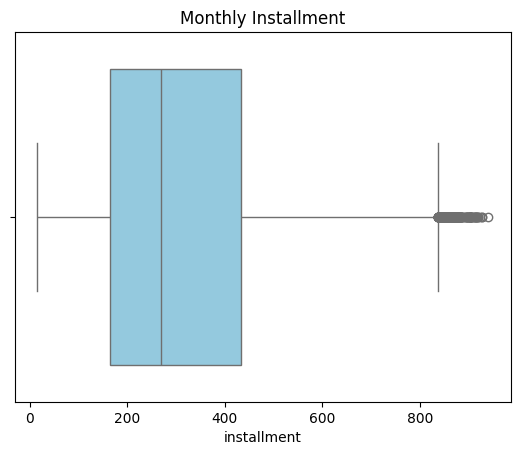

In [33]:
sns.boxplot(x=df["installment"],color="skyblue")
plt.title("Monthly Installment")
plt.show()

## **OBSERVATION**



* The Q1 value is less than 200 and Q3 value is greater than 400.
* The median installment values lie between 200-400.
* Several high installment values are outliers meaning that few people pay high monthly installments than the rest.



## BIVARIATE ANALYSIS

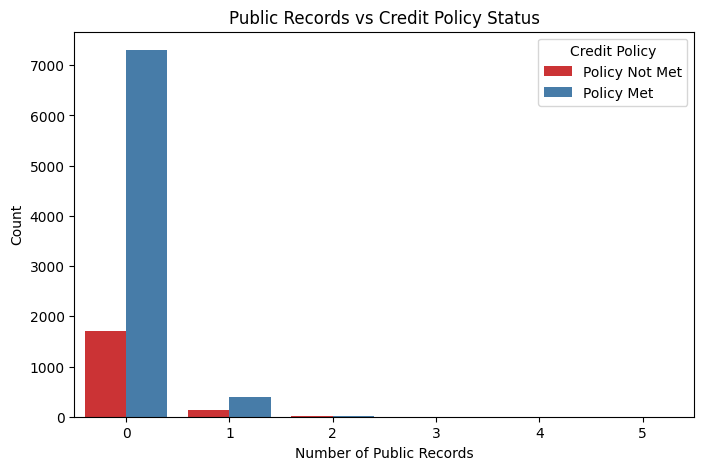

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="pub.rec",hue="credit.policy",data=df,palette="Set1")
plt.xlabel("Number of Public Records")
plt.ylabel("Count")
plt.title("Public Records vs Credit Policy Status")
plt.legend(title="Credit Policy",labels=["Policy Not Met", "Policy Met"])
plt.show()

## **OBSERVATION**



* Most borrowers have 0 public records, and the majority of them meet the credit policy.

* As the number of public records increases, the number of borrowers decreases across both credit policy groups.




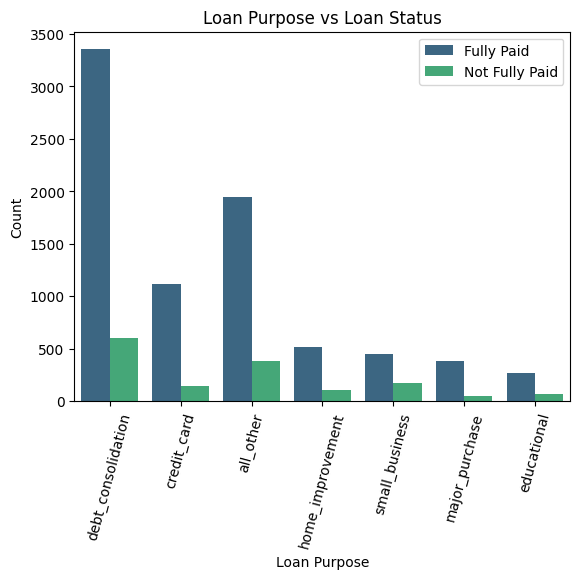

In [35]:
sns.countplot(x="purpose",hue="not.fully.paid",data=df,palette="viridis")
plt.xticks(rotation=75)
plt.title("Loan Purpose vs Loan Status")
plt.xlabel("Loan Purpose")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.show()

## **OBSERVATION**



* debt_consolidation loans are the most common.
* small_business loans generally show a higher proportion of defaults.
* educational** loans have relatively fewer observations.

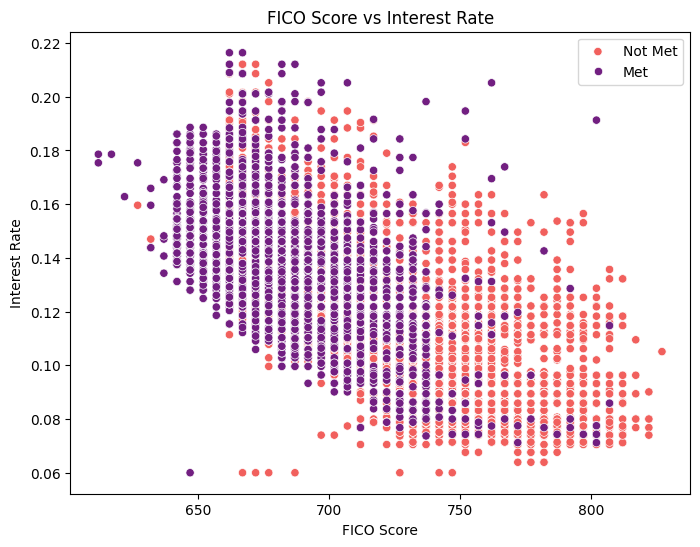

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="fico",y="int.rate",hue="credit.policy",data=df,palette="magma")
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate")
plt.legend(["Not Met","Met"])
plt.title("FICO Score vs Interest Rate")
plt.show()

## **OBSERVATION**


* Borrowers with higher FICO scores generally receive lower interest rates.
* Borrowers with lower FICO scores are more likely to have higher interest rates and greater credit risk.



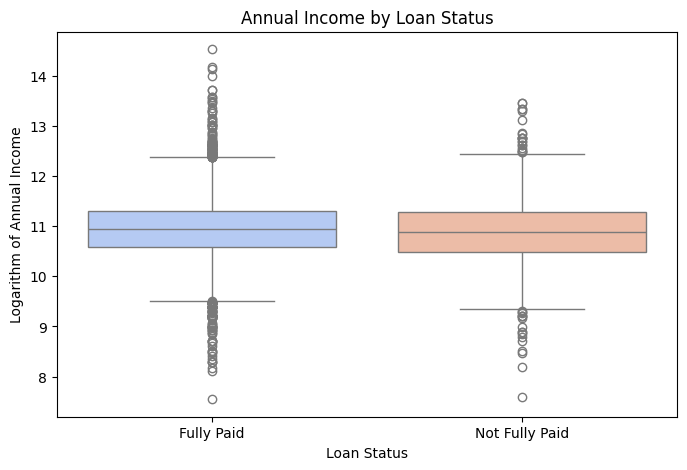

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x="not.fully.paid",y="log.annual.inc",data=df,palette="coolwarm")
plt.xticks([0,1],["Fully Paid","Not Fully Paid"])
plt.xlabel("Loan Status")
plt.ylabel("Logarithm of Annual Income")
plt.title("Annual Income by Loan Status")
plt.show()

## **OBSERVATION**



*   The median annual income is similar for both borrower groups.
* Both groups contain a few high and low income outliers.



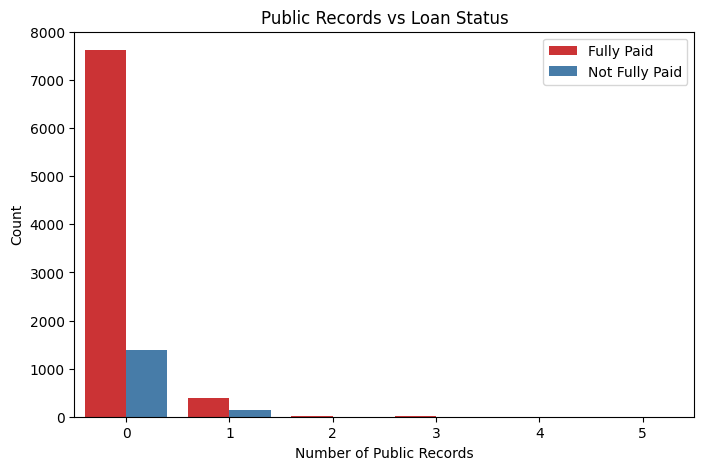

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x="pub.rec",hue="not.fully.paid",data=df,palette="Set1")
plt.xlabel("Number of Public Records")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.title("Public Records vs Loan Status")
plt.show()

## **OBSERVATION**



*   Most borrowers have zero public records.
* Borrowers with public records are fewer and have a higher chance of loan default.



In [39]:
df.groupby("credit.policy")["int.rate"].mean()

,int.rate
credit.policy,
0,0.138680
1,0.118754


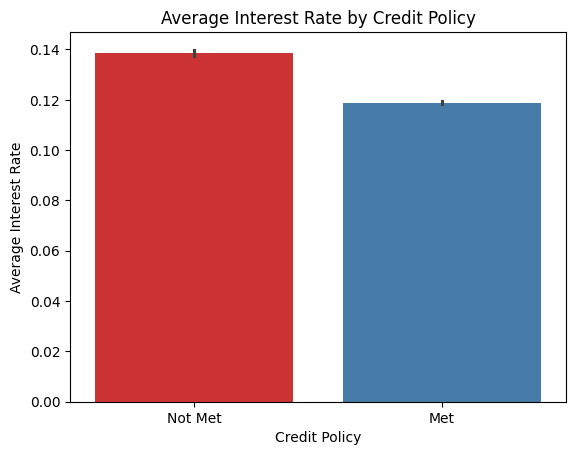

In [40]:
sns.barplot(x="credit.policy",y="int.rate",data=df,palette="Set1")
plt.xticks([0,1],["Not Met","Met"])
plt.xlabel("Credit Policy")
plt.ylabel("Average Interest Rate")
plt.title("Average Interest Rate by Credit Policy")
plt.show()

## **OBSERVATION**



*   Borrowers who did not meet the credit policy generally have higher average interest rates.



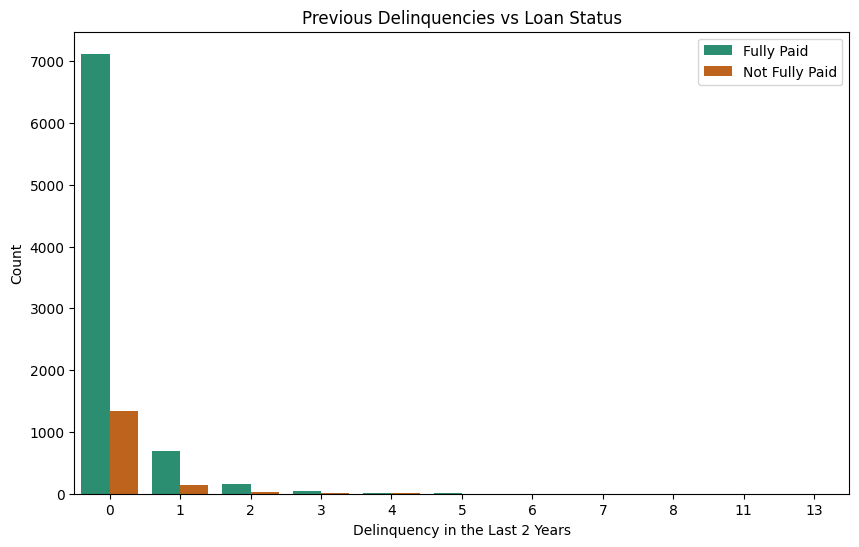

In [41]:
plt.figure(figsize=(10,6))
sns.countplot(x="delinq.2yrs",hue="not.fully.paid",data=df,palette="Dark2")
plt.xlabel("Delinquency in the Last 2 Years")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.title("Previous Delinquencies vs Loan Status")
plt.show()

## **OBSERVATION**

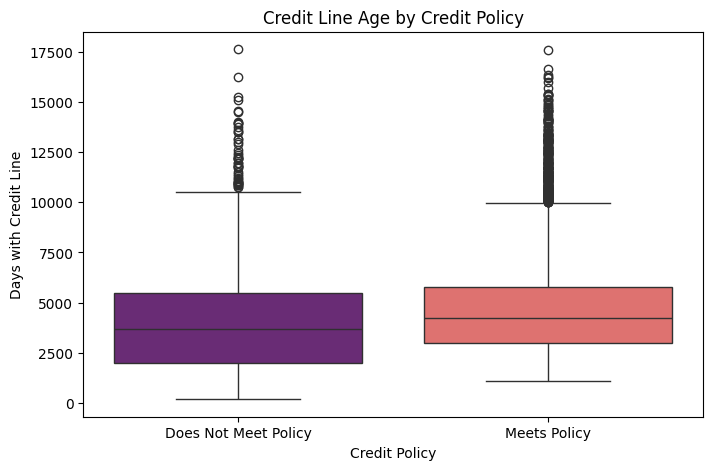

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="credit.policy",
    y="days.with.cr.line",
    data=df,
    palette="magma"
)
plt.xlabel("Credit Policy")
plt.ylabel("Days with Credit Line")
plt.xticks([0,1], ["Does Not Meet Policy", "Meets Policy"])
plt.title("Credit Line Age by Credit Policy")

plt.show()

## **OBSERVATION**



*   Borrowers who meet the credit policy generally have a slightly older credit history.
.
*   Both groups show many outliers, indicating some borrowers have very long credit histories.



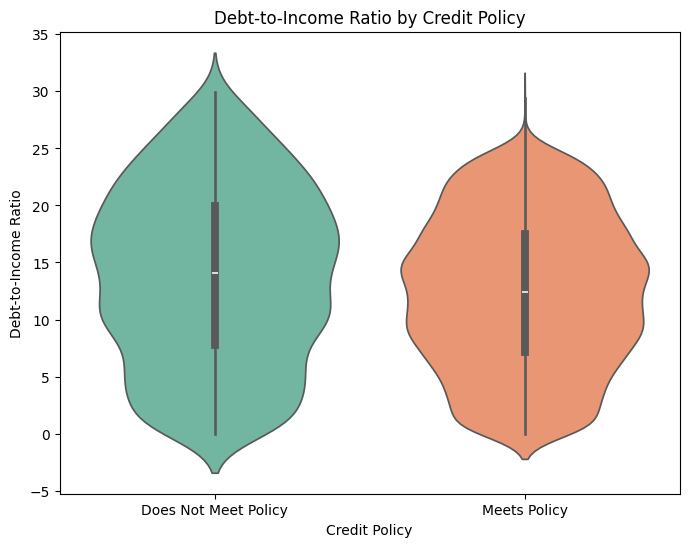

In [43]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x='credit.policy',
    y='dti',
    data=df,
    palette="Set2"
)

plt.xlabel("Credit Policy")
plt.ylabel("Debt-to-Income Ratio")
plt.xticks([0,1], ["Does Not Meet Policy", "Meets Policy"])
plt.title("Debt-to-Income Ratio by Credit Policy")

plt.show()

## **OBSERVATION**



*   Borrowers who meet the credit policy tend to have a slightly lower debt-to-income ratio.
* The debt-to-income ratio varies widely in both credit policy groups.




In [44]:
df['credit.policy'].value_counts()

,count
credit.policy,
1,7710
0,1868


In [45]:
df1=df.copy()

In [46]:
all_col = df1.select_dtypes(include=["number","object"])

In [47]:
all_col.shape

(9578, 14)

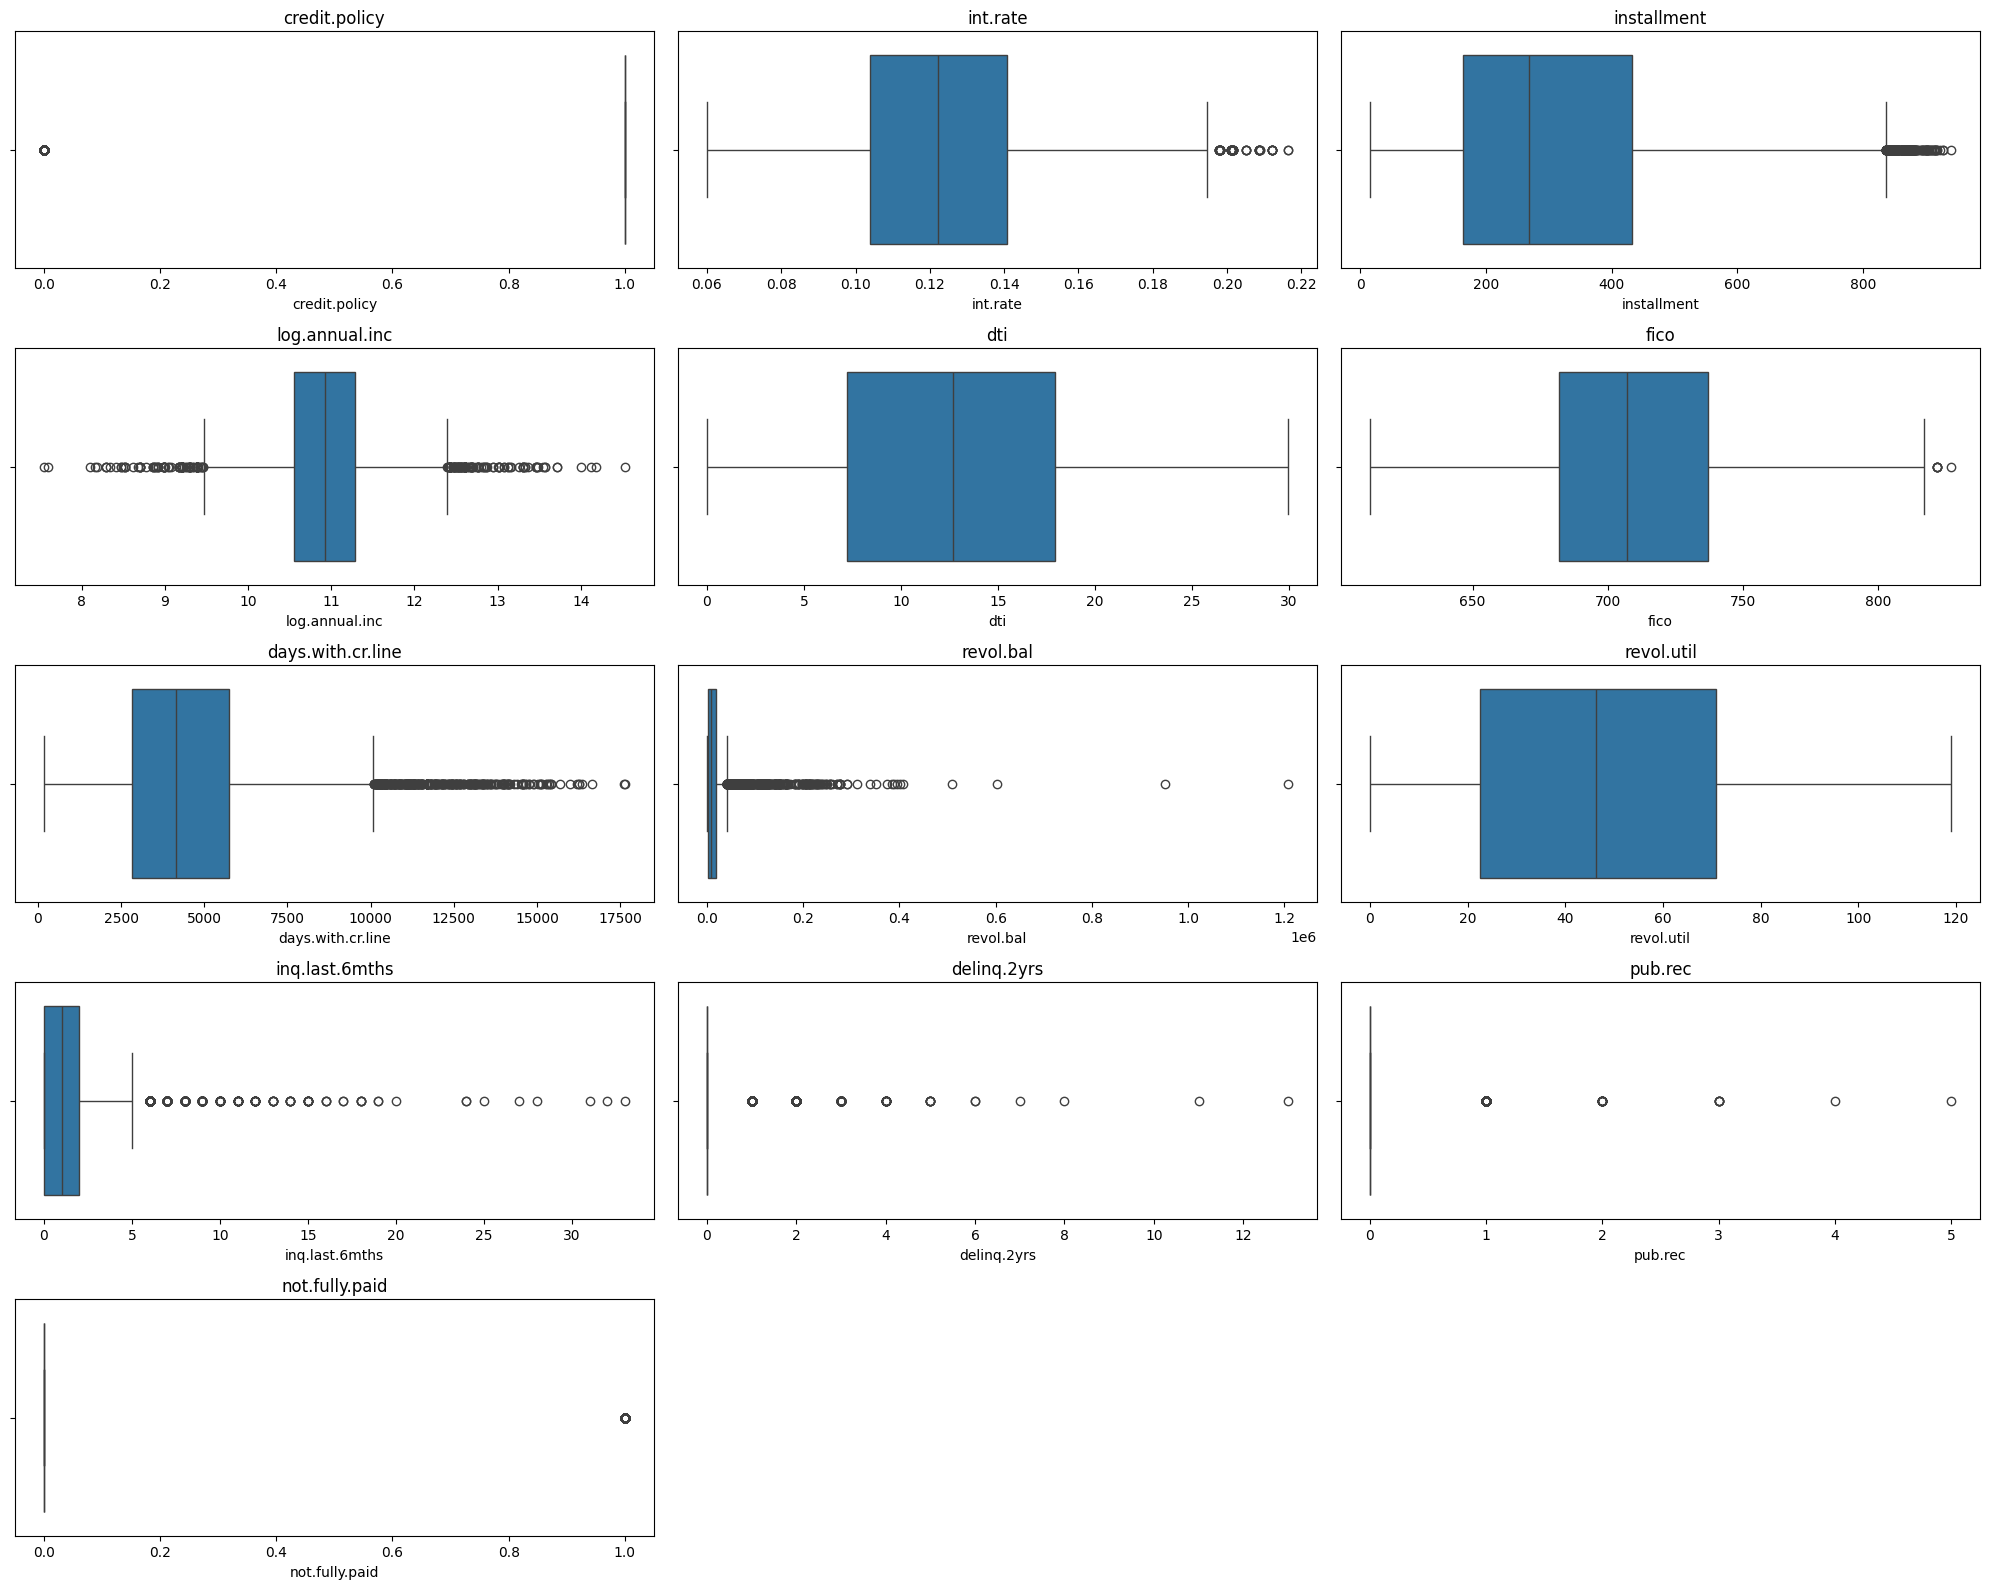

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = all_col.select_dtypes(include=['number']).columns

plt.figure(figsize=(20,16))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


## **OBSERVATION**



*   The numerical features show wide variation, reflecting differences in borrower and loan characteristics.

*   Most variables have a broad range of values, indicating diverse loan amounts, credit history, and financial profiles.



In [49]:
num_col=["int.rate","installment","log.annual.inc","dti","fico","days.with.cr.line","revol.bal","revol.util","inq.last.6mths","delinq.2yrs"]

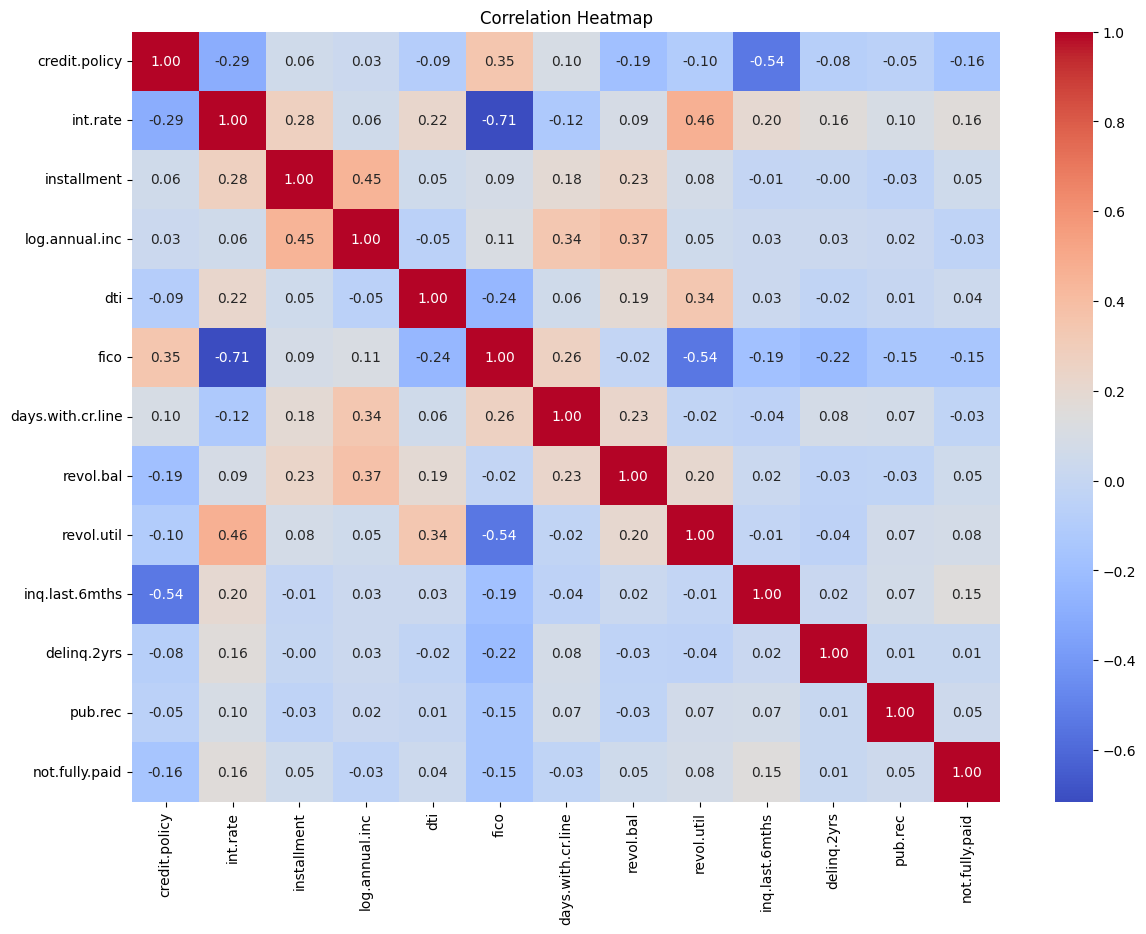

In [50]:
num_cols = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(14,10))
sns.heatmap(num_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **OBSERVATION**





*  Most features have weak to moderate correlations, indicating they provide distinct information.

*   A few feature pairs show strong positive correlations, suggesting related financial characteristics.





## **LABEL ENCODING**

In [51]:
from sklearn.preprocessing import LabelEncoder
le={}
LabelEncoder=LabelEncoder()
for col in df1.select_dtypes(include=["object"]).columns:
  df1[col]=LabelEncoder.fit_transform(df1[col])
  le[col]=LabelEncoder

## **TRAIN TEST SPLIT**

In [52]:
from sklearn.model_selection import train_test_split
y=df["credit.policy"]
X=df.drop(["credit.policy","not.fully.paid"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (6704, 12)
Testing data shape: (2874, 12)




*   Stored all predictor variables in X
*  We store the target variable (credit,policy) in y



Droping the not.fully.paid column because it can leak the data

In [53]:
df1.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


# **SMOTE**

In [54]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
scaler = StandardScaler()

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

if 'purpose' in X_train_enc.columns:
    X_train_enc['purpose'] = le['purpose'].transform(X_train_enc['purpose'])
    X_test_enc['purpose'] = le['purpose'].transform(X_test_enc['purpose'])

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Data:\n{y_train.value_counts()}")
print(f"Resampled Training Data:\n{y_train_resampled.value_counts()}")
X_test_scaled = scaler.transform(X_test_enc)


Original Training Data:
credit.policy
1    5397
0    1307
Name: count, dtype: int64
Resampled Training Data:
credit.policy
1    5397
0    5397
Name: count, dtype: int64


# **LOGISTIC REGRESSION**

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(random_state=42, max_iter=1000)


In [56]:
log_reg.fit(X_train_resampled, y_train_resampled)


LogisticRegression(max_iter=1000, random_state=42)

In [57]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f'Train Accuracy: {log_reg.score(X_train_resampled, y_train_resampled)}')
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8562978427279053
Train Accuracy: 0.8512136372058551
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.85      0.70       561
           1       0.96      0.86      0.91      2313

    accuracy                           0.86      2874
   macro avg       0.78      0.85      0.80      2874
weighted avg       0.89      0.86      0.87      2874

Confusion Matrix:
 [[ 478   83]
 [ 330 1983]]


In [59]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9344


**HYPERTUNING**

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [61]:
log_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
log_grid = GridSearchCV(log_reg, log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
log_grid.fit(X_train_resampled, y_train_resampled)

best_log_reg = log_grid.best_estimator_

y_train_pred_log = best_log_reg.predict(X_train_resampled)
y_test_pred_log = best_log_reg.predict(X_test_scaled)
y_train_pred_proba_log = best_log_reg.predict_proba(X_train_resampled)[:, 1]

print(f"Best Parameters: {log_grid.best_params_}")
print(f"Logistic Regression Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_log):.4f}")
print(f"Logistic Regression Testing Accuracy: {accuracy_score(y_test, y_test_pred_log):.4f}")
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred_log))

Best Parameters: {'C': 0.1}
Logistic Regression Training Accuracy: 0.8510
Logistic Regression Testing Accuracy: 0.8570

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       0.59      0.85      0.70       561
           1       0.96      0.86      0.91      2313

    accuracy                           0.86      2874
   macro avg       0.78      0.86      0.80      2874
weighted avg       0.89      0.86      0.87      2874



In [62]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9344


# **DECISION TREE**

In [63]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)


In [64]:
dt_clf.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(random_state=42)

In [65]:
y_pred = dt_clf.predict(X_test_scaled)
y_pred_proba = dt_clf.predict_proba(X_test_scaled)[:, 1]

In [66]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

Accuracy: 0.9826026443980515
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       561
           1       0.99      0.98      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.97      0.98      0.97      2874
weighted avg       0.98      0.98      0.98      2874

Confusion Matrix:
 [[ 546   15]
 [  35 2278]]
ROC AUC: 0.9790650843523355


**HYPERTUNING**

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [68]:
dt_param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(dt_clf, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_resampled, y_train_resampled)


best_dt = dt_grid.best_estimator_
y_train_pred_dt = best_dt.predict(X_train_resampled)
y_test_pred_dt = best_dt.predict(X_test_scaled)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Decision Tree Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_dt):.4f}")
print(f"Decision Tree Testing Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred_dt))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree Training Accuracy: 0.9860
Decision Tree Testing Accuracy: 0.9882

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.99      0.98      0.98      2874
weighted avg       0.99      0.99      0.99      2874



In [69]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9791


# **RANDOM FOREST**

In [70]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42)


In [71]:
rf_clf.fit(X_train_resampled, y_train_resampled)


RandomForestClassifier(random_state=42)

In [72]:
y_pred = rf_clf.predict(X_test_scaled)
y_pred_proba = rf_clf.predict_proba(X_test_scaled)[:, 1]

In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9860821155184412
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.98      0.97      0.98      2874
weighted avg       0.99      0.99      0.99      2874

Confusion Matrix:
 [[ 531   30]
 [  10 2303]]
ROC AUC: 0.9973


**HYPERTUNING**

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV




In [75]:
rf_clf_rs = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_param_dist = {
    "max_depth":[5,8,10,12,15],
    "min_samples_split":[5,10,15,20,30],
    "min_samples_leaf":[2,4,6,8,10],
    "max_features":["sqrt","log2",0.3,0.5],
    "bootstrap":[True],
    "max_samples":[0.6,0.7,0.8,0.9],
    "class_weight":["balanced","balanced_subsample"]
}


In [76]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_clf_rs,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)


In [77]:
rf_random_search.fit(X_train_resampled, y_train_resampled)


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [5, 8, 10, 12, 15],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'max_samples': [0.6, 0.7, 0.8, 0.9],
                                        'min_samples_leaf': [2, 4, 6, 8, 10],
                                        'min_samples_split': [5, 10, 15, 20,
                                                              30]},
                   random_state=42, scoring='roc_auc')

In [78]:
best_rf_rs = rf_random_search.best_estimator_


In [79]:
print(best_rf_rs.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 0.3, 'max_leaf_nodes': None, 'max_samples': 0.9, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 15, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [80]:
rf_random_search.best_params_


{'min_samples_split': 15,
 'min_samples_leaf': 4,
 'max_samples': 0.9,
 'max_features': 0.3,
 'max_depth': 12,
 'class_weight': 'balanced',
 'bootstrap': True}

In [81]:
rf_random_search.best_score_

np.float64(0.9980361930840255)

In [82]:
y_train_pred_fast = best_rf_rs.predict(X_train_resampled)
y_test_pred_fast = best_rf_rs.predict(X_test_scaled)
y_train_prob_fast = best_rf_rs.predict_proba(X_train_resampled)[:, 1]
y_test_prob_fast = best_rf_rs.predict_proba(X_test_scaled)[:, 1]



In [83]:
from sklearn.metrics import roc_auc_score

print(f"\nBest Hyperparameters: {rf_random_search.best_params_}")
print(f"Optimized RF Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_fast):.4f}")
print(f"Optimized RF Testing Accuracy:  {accuracy_score(y_test, y_test_pred_fast):.4f}")
print(f"Optimized RF Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_fast):.4f}")
print(f"Optimized RF Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_fast):.4f}")
print("\nClassification Report on Test Data:\n", classification_report(y_test, y_test_pred_fast))


Best Hyperparameters: {'min_samples_split': 15, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 0.3, 'max_depth': 12, 'class_weight': 'balanced', 'bootstrap': True}
Optimized RF Training Accuracy: 0.9853
Optimized RF Testing Accuracy:  0.9843
Optimized RF Training ROC AUC:  0.9995
Optimized RF Testing ROC AUC:   0.9965

Classification Report on Test Data:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       561
           1       0.99      0.99      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.98      0.97      0.97      2874
weighted avg       0.98      0.98      0.98      2874



In [84]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


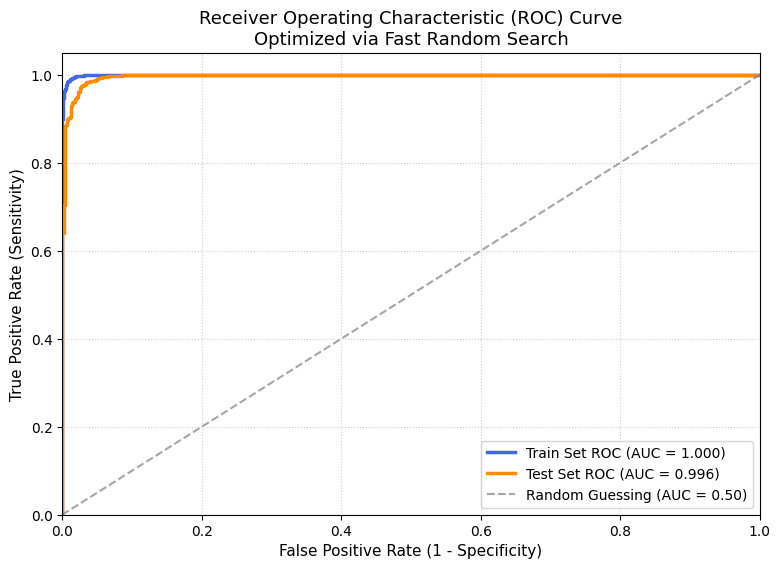

In [85]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **XG BOOST**

In [86]:
!pip install xgboost

In [87]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_base.fit(X_train_resampled, y_train_resampled)

y_train_pred_xgb_base = xgb_base.predict(X_train_resampled)
y_test_pred_xgb_base = xgb_base.predict(X_test_scaled)

y_train_prob_xgb_base = xgb_base.predict_proba(X_train_resampled)[:, 1]
y_test_prob_xgb_base = xgb_base.predict_proba(X_test_scaled)[:, 1]

print(f"Base XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_base):.4f}")
print(f"Base XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_base):.4f}")
print(f"Base XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_base):.4f}")
print(f"Base XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_base):.4f}")
print("\nClassification Report (Base):\n", classification_report(y_test, y_test_pred_xgb_base))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb_base))

Base XGBoost Training Accuracy: 1.0000
Base XGBoost Testing Accuracy:  0.9896
Base XGBoost Training ROC AUC:  1.0000
Base XGBoost Testing ROC AUC:   0.9975

Classification Report (Base):
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.99      0.98      0.98      2874
weighted avg       0.99      0.99      0.99      2874

Confusion Matrix:
 [[ 539   22]
 [   8 2305]]


In [88]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


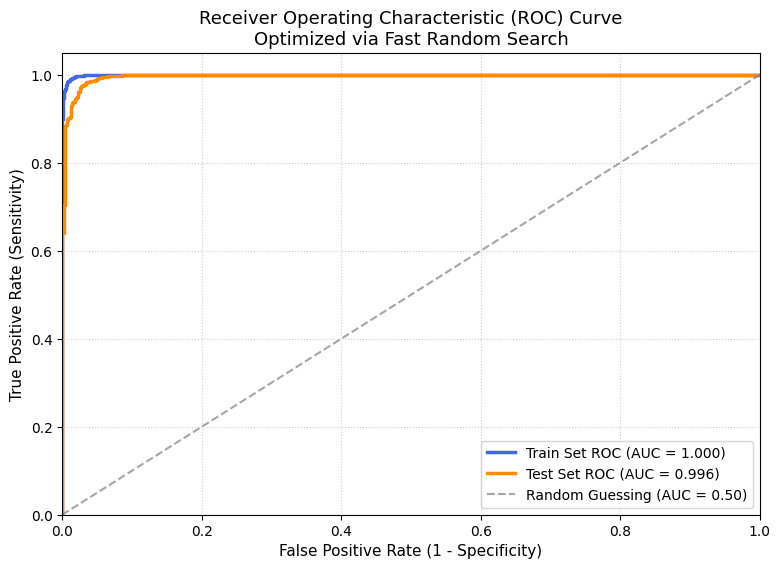

In [89]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [90]:
#from sklearn.model_selection import RandomizedSearchCV

#xgb_tune = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

#xgb_param_dist = {
    # 'n_estimators': [100, 200, 300],
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # 'max_depth': [3, 4, 5, 6],
    # 'subsample': [0.6, 0.8, 1.0],
    # 'colsample_bytree': [0.6, 0.8, 1.0],
    # 'gamma': [0, 1, 2, 5]
    #"n_estimators": [200,300,500,700],
    #"gamma": [1,2,3,5],
    #"subsample": [0.6,0.7,0.8],
    #"colsample_bytree": [0.6,0.7,0.8],
    #"reg_alpha": [0,0.1,0.5,1,5],
    #"reg_lambda": [1,5,10,20],
    #"scale_pos_weight": [1,2,3,4]
#}

#xgb_random_search = RandomizedSearchCV(
    #estimator=xgb_tune,
    #param_distributions=xgb_param_dist,
    #n_iter=30,
    #cv=5,
    #scoring='roc_auc',
    #random_state=42,
    #n_jobs=-1
#)

#xgb_random_search.fit(X_train_resampled, y_train_resampled)

#best_xgb = xgb_random_search.best_estimator_

#y_train_pred_xgb_best = best_xgb.predict(X_train_resampled)
#y_test_pred_xgb_best = best_xgb.predict(X_test_scaled)

#y_train_prob_xgb_best = best_xgb.predict_proba(X_train_resampled)[:, 1]
#y_test_prob_xgb_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

#print(f"Best Hyperparameters: {xgb_random_search.best_params_}\n")
#print(f"Tuned XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_best):.4f}")
#print(f"Tuned XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_best):.4f}")
#print(f"Tuned XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_best):.4f}")
#print(f"Tuned XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_best):.4f}")
#print("\nClassification Report (Tuned):\n", classification_report(y_test, y_test_pred_xgb_best))

In [91]:
#from sklearn.metrics import roc_curve, auc
#fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
#fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
#auc_train = auc(fpr_train, tpr_train)
#auc_test = auc(fpr_test, tpr_test)


In [92]:
#plt.figure(figsize=(9, 6))
#plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
#plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
#plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
#plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
#plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
#plt.legend(loc="lower right", frameon=True)
#plt.grid(True, linestyle=':', alpha=0.6)
#plt.show()

**HYPERTUNING**

In [93]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

xgb_tune = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_param_dist = {
    "n_estimators": [50, 80, 100],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "min_child_weight": [2, 5, 8],
    "gamma": [0, 1, 2],
    "subsample": [0.75, 0.85, 0.95],
    "colsample_bytree": [0.75, 0.85, 0.95],
    "reg_alpha": [0.1, 1, 5],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_random_search.best_estimator_

y_train_pred_xgb_best = best_xgb.predict(X_train_resampled)
y_test_pred_xgb_best = best_xgb.predict(X_test_scaled)

y_train_prob_xgb_best = best_xgb.predict_proba(X_train_resampled)[:, 1]
y_test_prob_xgb_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Best Hyperparameters: {xgb_random_search.best_params_}\n")
print(f"Tuned XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_best):.4f}")
print(f"Tuned XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_best):.4f}")
print(f"Tuned XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_best):.4f}")
print(f"Tuned XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_best):.4f}")
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_test_pred_xgb_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb_best))

Best Hyperparameters: {'subsample': 0.95, 'scale_pos_weight': 1, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.85}

Tuned XGBoost Training Accuracy: 0.9872
Tuned XGBoost Testing Accuracy:  0.9861
Tuned XGBoost Training ROC AUC:  0.9995
Tuned XGBoost Testing ROC AUC:   0.9961

Classification Report (Tuned):
               precision    recall  f1-score   support

           0       0.99      0.94      0.96       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.99      0.97      0.98      2874
weighted avg       0.99      0.99      0.99      2874

Confusion Matrix:
 [[ 527   34]
 [   6 2307]]


In [94]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


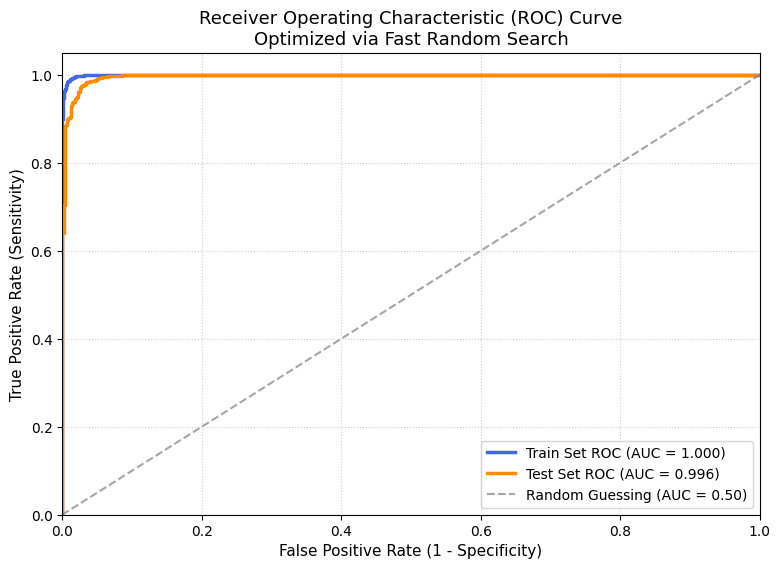

In [95]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **MODEL COMPARISION**

In [150]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd


# Predictions from all models

models = {
    "Logistic Regression": best_log_reg,
    "Decision Tree": best_dt,
    "Random Forest": best_rf_rs,
    "XGBoost": best_xgb
}


comparison = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    comparison.append([
        name,
        round(accuracy_score(y_test, y_pred),2),
        round(precision_score(y_test, y_pred),2),
        round(recall_score(y_test, y_pred),2),
        round(f1_score(y_test, y_pred),2),
        round(roc_auc_score(y_test, y_prob),3)
    ])


model_comparison = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)


model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.86,0.96,0.86,0.91,0.934
1,Decision Tree,0.99,0.99,1.00,0.99,0.983
2,Random Forest,0.98,0.99,0.99,0.99,0.996
3,XGBoost,0.99,0.99,1.00,0.99,0.996


# **MODEL VALIDATION**

In [140]:
from sklearn.model_selection import cross_val_score
import numpy as np

### **LOGISTIC REGRESSION CV**

In [145]:

lr_cv = cross_val_score(
    best_log_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)


print("Logistic Regression Cross Validation Scores:")
print(lr_cv)

print("Mean Accuracy:",
      lr_cv.mean())
print("Standard Deviation:",
      lr_cv.std())

Logistic Regression Cross Validation Scores:
[0.90231171 0.90380313 0.91498881 0.89261745 0.9       ]
Mean Accuracy: 0.902744220730798
Standard Deviation: 0.00722939378306658


### **DECISION TREE CV**

In [146]:

dt_cv = cross_val_score(
    best_dt,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)


print("Decision Tree Cross Validation Scores:")
print(dt_cv)

print("Mean Accuracy:",
      dt_cv.mean())
print("Standard Deviation:",
      dt_cv.std())

Decision Tree Cross Validation Scores:
[0.99030574 0.9940343  0.98583147 0.98956003 0.99179104]
Mean Accuracy: 0.9903045176800562
Standard Deviation: 0.00270863387057015


### **RANDOM FOREST CV**

In [148]:

rf_cv = cross_val_score(
    best_rf_rs,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)


print("Random Forest Cross Validation Scores:")
print(rf_cv)

print("Mean Accuracy:",
      rf_cv.mean())
print("Standard Deviation:",
      rf_cv.std())

Random Forest Cross Validation Scores:
[0.98583147 0.98508576 0.98284862 0.98434004 0.99179104]
Mean Accuracy: 0.9859793871804291
Standard Deviation: 0.0030687118770535864


### **XGBOOST CV**

In [149]:

xgb_cv = cross_val_score(
    best_xgb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)


print("XGBoost Cross Validation Scores:")
print(xgb_cv)

print("Mean Accuracy:",
      xgb_cv.mean())
print("Standard Deviation:",
      xgb_cv.std())

XGBoost Cross Validation Scores:
[0.98434004 0.98657718 0.98284862 0.9813572  0.9880597 ]
Mean Accuracy: 0.984636548799626
Standard Deviation: 0.0024299294223337213


# **FEATURE IMPORTANCE**

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = best_xgb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
9      inq.last.6mths    0.307528
5                fico    0.253317
6   days.with.cr.line    0.187467
4                 dti    0.092527
7           revol.bal    0.087588
3      log.annual.inc    0.019631
0             purpose    0.019168
1            int.rate    0.014153
8          revol.util    0.008062
2         installment    0.006451
10        delinq.2yrs    0.004107
11            pub.rec    0.000000


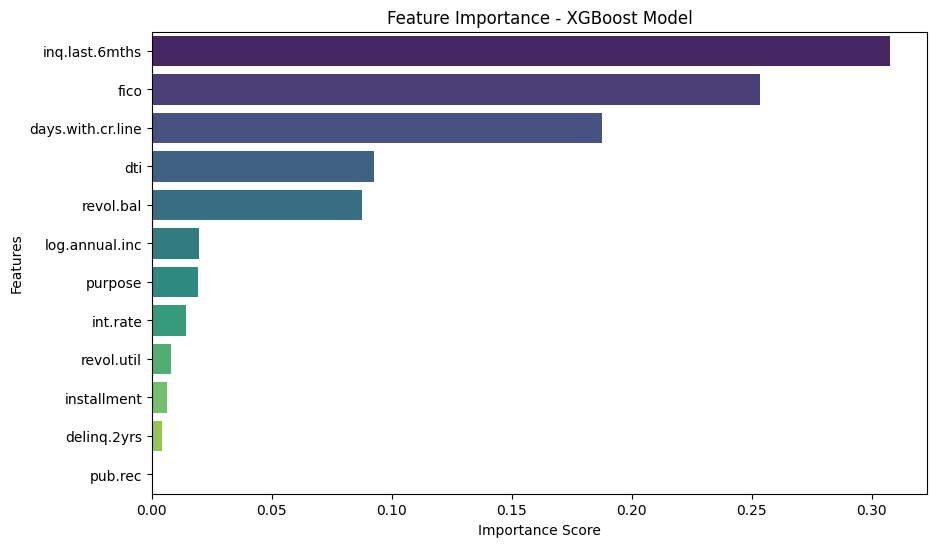

In [98]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette='viridis'
)

plt.title("Feature Importance - XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## **OBSERVATION**



*   'inq.last.6mths ` and ` fico` are the most important features, indicating they have the highest influence on predicting credit policy status.
* Features like `days.with.cr.line`, `dti`, and `revol.bal` contribute moderately, while `pub.rec` and `delinq.2yrs` have lower importance in the model.





# **NEW TRIALS**

In [99]:
df1.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [100]:
df1.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,0,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,0,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,2,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,2,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


**XGBOOST**

In [101]:
input_data=np.array([[2, 0.1471, 354.76, 12.180755, 9.39, 672, 10474.0, 215372, 82.1, 2, 2, 0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled)

array([0])

In [102]:
input_data=np.array([[2,0.1392,853.43,12.264464,16.28,732,4740.000000,37880,57.0,6,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [103]:
input_data=np.array([[1,0.1426,108.92,11.300732,14.97,667,4066.000000,4740,39.5,0,1,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [104]:
input_data=np.array([[4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,4.2,5,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [105]:
input_data=np.array([[1,0.1081,328.22,11.082143,14.29,707,2760.000000,33623,76.7,2,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [106]:
input_data=np.array([[2,0.0863,219.54,8.487972,9.73,727,1559.958333,7282,44.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [107]:
input_data=np.array([[6,0.0714,92.82,12.512925,6.50,747,4384.000000,4021,5.8,0,1,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [108]:
input_data=np.array([[1,0.1114,131.22,11.002100,11.08,722,5116.000000,34220,78.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [109]:
input_data=np.array([[2,0.1099,560.50,12.235243,17.84,727,6840.041667,18753,29.0,4,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [110]:
input_data=np.array([[0,0.1385,511.56,12.323856,12.33,687,6420.041667,485489,51.2,4,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

**XGB: 9/10**

In [111]:
new_data=pd.read_csv('/content/loan_data.csv')

In [112]:
new_data.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [113]:
newdataX=new_data.drop(columns=['credit.policy', 'not.fully.paid'])
newdataX

,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0
1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0
2,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0
3,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0
4,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9573,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0
9574,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0
9575,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0
9576,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0


In [114]:
newdataY=(['credit.policy'])

In [115]:
newdataX_enc = newdataX.copy()
newdataX_enc['purpose'] = le['purpose'].transform(newdataX_enc['purpose'])

newdataX_scaled = scaler.transform(newdataX_enc)

newdatapred = best_xgb.predict(newdataX_scaled)
newdataY = new_data['credit.policy']
print('Accuracy: ', accuracy_score(newdataY, newdatapred))

Accuracy:  0.9899770306953435


**RANDOM FOREST**

In [116]:
input_data=np.array([[0, 0, 0.1471, 354.76, 12.180755, 10.39, 672, 10474.0, 215372, 82.1, 2, 0, ]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled)

array([0])

In [117]:
input_data=np.array([[2,0.1392,853.43,12.264464,16.28,732,4740.000000,37880,57.0,6,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

In [118]:
input_data=np.array([[1,0.1426,108.92,11.300732,14.97,667,4066.000000,4740,39.5,0,1,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [119]:
input_data=np.array([[4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,4.2,5,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

In [120]:
input_data=np.array([[1,0.1081,328.22,11.082143,14.29,707,2760.000000,33623,76.7,2,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [121]:
df1.head(15)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,1,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0
6,1,2,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1
7,1,0,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1
8,1,4,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0
9,1,2,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0


In [122]:
input_data=np.array([[2,0.0863,219.54,8.487972,9.73,727,1559.958333,7282,44.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [123]:
input_data=np.array([[6,0.0714,92.82,12.512925,6.50,747,4384.000000,4021,5.8,0,1,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [124]:
input_data=np.array([[0,0.1114,131.22,11.002100,11.08,722,5116.000000,34220,78.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [125]:
df1.tail(15)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9563,0,2,0.1099,556.50,11.225243,17.84,727,6840.041667,18753,29.0,4,0,0,1
9564,0,0,0.1385,511.56,12.323856,12.33,687,6420.041667,385489,51.2,4,0,0,0
9565,0,0,0.1459,396.35,10.308953,21.04,697,3390.000000,26117,78.4,6,0,0,1
9566,0,0,0.2164,551.08,11.002100,24.06,662,1800.000000,16441,49.8,9,0,0,1
9567,0,0,0.1311,101.24,10.968198,8.23,687,2790.041667,1514,13.8,5,0,0,0
9568,0,0,0.1979,37.06,10.645425,22.17,667,5916.000000,28854,59.8,6,0,1,0
9569,0,4,0.1426,823.34,12.429216,3.62,722,3239.958333,33575,83.9,5,0,0,1
9570,0,0,0.1671,113.63,10.645425,28.06,672,3210.041667,25759,63.8,5,0,0,1
9571,0,0,0.1568,161.01,11.225243,8.00,677,7230.000000,6909,29.2,4,0,1,1
9572,0,2,0.1565,69.98,10.110472,7.02,662,8190.041667,2999,39.5,6,0,0,1


In [126]:
input_data=np.array([[2,0.1099,560.50,12.235243,17.84,727,6840.041667,18753,29.0,4,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled)

array([0])

In [127]:
input_data=np.array([[0,0.1385,511.56,12.323856,12.33,687,6420.041667,485489,51.2,4,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

**Random forest:8/10**

**LOGISTIC REGRESSION**

In [128]:
input_data=np.array([[ 0, 0.1471, 354.76, 12.180755, 10.39, 672, 10474.0, 215372, 82.1, 2, 0, 0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([0])

In [129]:
input_data=np.array([[2,0.1392,853.43,12.264464,16.28,732,4740.000000,37880,57.0,6,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([0])

In [130]:
input_data=np.array([[1,0.1426,108.92,11.300732,14.97,667,4066.000000,4740,39.5,0,1,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([1])

In [131]:
input_data=np.array([[4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,4.2,5,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([0])

In [132]:
input_data=np.array([[1,0.1081,328.22,11.082143,14.29,707,2760.000000,33623,76.7,2,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([1])

In [133]:
input_data=np.array([[2,0.0863,219.54,8.487972,9.73,727,1559.958333,7282,44.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled)

array([1])

In [134]:
input_data=np.array([[6,0.0714,92.82,12.512925,6.50,747,4384.000000,4021,5.8,0,1,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled) #correct

array([1])

In [135]:
input_data=np.array([[0,0.1114,131.22,11.002100,11.08,722,5116.000000,34220,78.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled)

array([1])

In [136]:
input_data=np.array([[2,0.1099,560.50,12.235243,17.84,727,6840.041667,18753,29.0,4,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled)

array([1])

In [137]:
input_data=np.array([[0,0.1385,511.56,12.323856,12.33,687,6420.041667,485489,51.2,4,0,0]])
input_scaled=scaler.transform(input_data)
best_log_reg.predict(input_scaled)

array([0])

**Logistic Regression: 6/10**